# Part 2 — Zipf's law on *Pride and Prejudice*

**Course:** ECE328 Information Retrieval — University of Thessaly  
**Author:** Nikos Mavros (AEM 03741)

Zipf's law states that, for a large corpus, the collection frequency of the *i*-th most frequent term is approximately

$$\mathrm{cf}_i \;\approx\; \frac{c}{i}$$

for some constant *c*. Equivalently, in log–log space, $\log \mathrm{cf}_i = \log c - \log i$, a straight line with slope $-1$.

This notebook tests the law on Jane Austen's *Pride and Prejudice* (Project Gutenberg eBook #1342). **No stemming** is applied, per assignment instructions.

## Pipeline
1. Download the Plain Text UTF-8 version of the novel.
2. Strip Project Gutenberg boilerplate (header, license, transcriber notes).
3. Tokenise: Unicode-aware lowercase + alphabetic words (apostrophes preserved inside contractions like *don't*).
4. Count frequencies, sort by rank.
5. Estimate the Zipf constant *c* (three estimators; report the most robust).
6. Plot the frequency–rank curve for the top 50 terms, plus the log–log fit.

In [1]:
import re
import os
import urllib.request
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path('../data')
FIG_DIR = Path('../results/figures')
TBL_DIR = Path('../results/tables')
for d in (DATA_DIR, FIG_DIR, TBL_DIR):
    d.mkdir(parents=True, exist_ok=True)

BOOK_PATH = DATA_DIR / 'pride_and_prejudice.txt'
BOOK_URL = 'https://www.gutenberg.org/ebooks/1342.txt.utf-8'

## 1. Download (one-time)

Downloads the canonical Plain Text UTF-8 version from Project Gutenberg if not already cached locally.

In [2]:
if not BOOK_PATH.exists():
    print(f'Downloading from {BOOK_URL}...')
    req = urllib.request.Request(BOOK_URL, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=30) as r:
        text = r.read().decode('utf-8')
    BOOK_PATH.write_text(text, encoding='utf-8')
    print(f'Saved {len(text):,} characters to {BOOK_PATH}')
else:
    text = BOOK_PATH.read_text(encoding='utf-8')
    print(f'Using cached copy: {len(text):,} characters from {BOOK_PATH}')

Using cached copy: 763,083 characters from ..\data\pride_and_prejudice.txt


## 2. Strip Project Gutenberg boilerplate

Project Gutenberg files are wrapped in a header (license, metadata) and footer (license, donation info). We keep only the content between the START and END markers.

In [3]:
START_MARKER = '*** START OF THE PROJECT GUTENBERG EBOOK'
END_MARKER = '*** END OF THE PROJECT GUTENBERG EBOOK'

def strip_gutenberg_boilerplate(raw: str) -> str:
    start = raw.find(START_MARKER)
    end = raw.find(END_MARKER)
    if start == -1 or end == -1:
        return raw
    # Skip past the start marker line
    start = raw.find('\n', start) + 1
    return raw[start:end]

body = strip_gutenberg_boilerplate(text)
print(f'Stripped body length: {len(body):,} characters')
print('First 200 characters of stripped body:')
print(repr(body[:200]))

Stripped body length: 743,288 characters
First 200 characters of stripped body:
'\n\n\n\n\n\n\n\n\n                            [Illustration:\n\n\n\n                             GEORGE ALLEN\n\n                               PUBLISHER\n\n\n\n                        156 CHARING CROSS ROAD\n\n          '


## 3. Tokenise — no stemming

Steps:
- Normalise Unicode curly quotes (`\u2019`, `\u2018`) to ASCII apostrophes so contractions tokenise consistently.
- Lower-case.
- Extract alphabetic words. Apostrophes inside words are preserved (e.g. `don't`, `I'll`, `Mr.`'s `Mr` token), so a contraction stays as one token. This is a common convention in IR.
- **No stemming.** The assignment is explicit on this; *running* and *runs* count separately.

In [4]:
TOKEN_REGEX = re.compile(r"[a-z]+(?:'[a-z]+)?")

def tokenise(s: str) -> list[str]:
    s = s.replace('\u2019', "'").replace('\u2018', "'")
    return TOKEN_REGEX.findall(s.lower())

tokens = tokenise(body)
vocab = set(tokens)
print(f'Total tokens (running words): {len(tokens):,}')
print(f'Vocabulary size (distinct types): {len(vocab):,}')

Total tokens (running words): 127,864
Vocabulary size (distinct types): 6,821


## 4. Frequency table

In [5]:
freq = Counter(tokens)
ranked = freq.most_common()
df = pd.DataFrame(ranked, columns=['term', 'cf'])
df['rank'] = np.arange(1, len(df) + 1)
df['cf_times_rank'] = df['cf'] * df['rank']
df.head(20)

,term,cf,rank,cf_times_rank
0,the,4663,1,4663
1,to,4325,2,8650
2,of,3844,3,11532
3,and,3767,4,15068
4,her,2284,5,11420
5,i,2119,6,12714
6,a,2038,7,14266
7,in,1994,8,15952
8,was,1875,9,16875
9,she,1751,10,17510


## 5. Estimate the Zipf constant *c*

Three estimators:

**(a) Raw most-frequent term.** If $\mathrm{cf}_i = c/i$, then $c = \mathrm{cf}_1 \cdot 1 = \mathrm{cf}_1$. Cheap but only uses one data point and Zipf's law fits the head poorly.

**(b) Average of $\mathrm{cf}_i \cdot i$ across ranks.** If the law held perfectly the product would be constant; in practice it varies, so the mean (or median) is a robust estimator.

**(c) Least-squares fit in log–log space.** Fit $\log \mathrm{cf} = a - b \log i$ and report $c = e^{a}$. We also recover the exponent $b$, which Zipf predicts to be $1$.

Estimator (c) is the standard choice and what we report as the headline number; (a) and (b) are sanity checks.

In [6]:
ranks = df['rank'].to_numpy()
cfs = df['cf'].to_numpy()

# (a) cf_1 estimator
c_a = cfs[0]

# (b) mean of cf * i across ALL ranks
c_b_mean = float(np.mean(cfs * ranks))
c_b_median = float(np.median(cfs * ranks))

# (c) least-squares log-log fit (over top N to avoid the long flat tail of hapax legomena)
TOP_N_FOR_FIT = 1000
log_r = np.log(ranks[:TOP_N_FOR_FIT])
log_cf = np.log(cfs[:TOP_N_FOR_FIT])
slope, intercept = np.polyfit(log_r, log_cf, 1)
c_c = float(np.exp(intercept))
exponent = float(-slope)

print(f'(a) cf_1 estimator           : c = {c_a:>10,.2f}')
print(f'(b) mean(cf_i * i) all ranks : c = {c_b_mean:>10,.2f}')
print(f'    median(cf_i * i)         : c = {c_b_median:>10,.2f}')
print(f'(c) log-log fit (top {TOP_N_FOR_FIT})  : c = {c_c:>10,.2f},  exponent = {exponent:.3f}')
print()
print(f'Reported constant: c ≈ {c_a:,.0f}  (cf_1 boundary condition)')
print(f'Empirical exponent: {exponent:.3f}  (Zipf predicts 1.0)')

(a) cf_1 estimator           : c =   4,663.00
(b) mean(cf_i * i) all ranks : c =   8,733.54
    median(cf_i * i)         : c =   7,788.00
(c) log-log fit (top 1000)  : c =  24,874.39,  exponent = 1.080

Reported constant: c ≈ 4,663  (cf_1 boundary condition)
Empirical exponent: 1.080  (Zipf predicts 1.0)


## 6. Plots

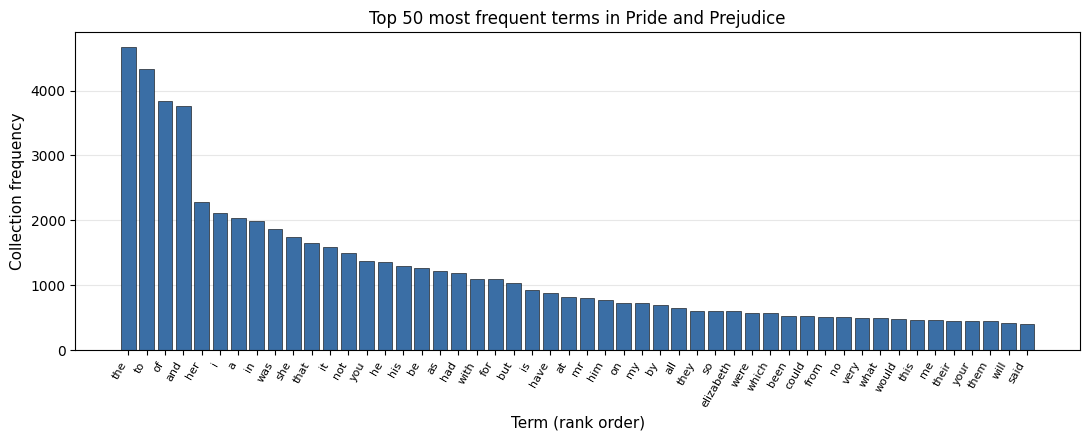

In [7]:
# Figure 1: top-50 term-vs-frequency bar chart (linear scale)
TOP = 50
top_df = df.head(TOP)

fig, ax = plt.subplots(figsize=(11, 4.5))
bars = ax.bar(range(1, TOP + 1), top_df['cf'], color='#3a6ea5', edgecolor='black', linewidth=0.4)
ax.set_xticks(range(1, TOP + 1))
ax.set_xticklabels(top_df['term'], rotation=60, ha='right', fontsize=8)
ax.set_xlabel('Term (rank order)', fontsize=11)
ax.set_ylabel('Collection frequency', fontsize=11)
ax.set_title(f"Top {TOP} most frequent terms in Pride and Prejudice", fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(FIG_DIR / 'zipf_top50_bar.pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'zipf_top50_bar.png', dpi=160, bbox_inches='tight')
plt.show()

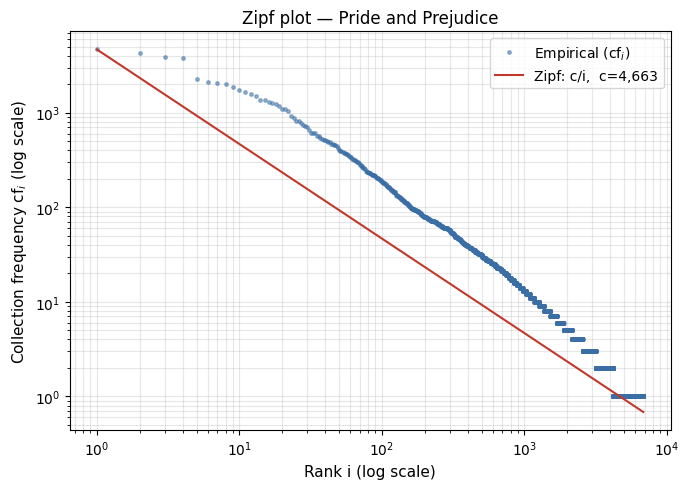

In [8]:
# Figure 2: log-log frequency vs rank, with Zipf prediction overlaid
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(ranks, cfs, 'o', markersize=2.5, alpha=0.5,
          color='#3a6ea5', label='Empirical (cf$_i$)')

# Zipf prediction: c / i with the fitted constant
ax.loglog(ranks, c_a / ranks, '-', color='#c0392b', linewidth=1.5,
          label=f'Zipf: c/i,  c={c_a:,.0f}')

ax.set_xlabel('Rank i (log scale)', fontsize=11)
ax.set_ylabel('Collection frequency cf$_i$ (log scale)', fontsize=11)
ax.set_title('Zipf plot — Pride and Prejudice', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'zipf_loglog.pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'zipf_loglog.png', dpi=160, bbox_inches='tight')
plt.show()

## 7. Save tables

In [9]:
# Save the top-50 to a CSV for the report
df.head(50).to_csv(TBL_DIR / 'zipf_top50.csv', index=False)

# Save the constant estimates for the report
constants_df = pd.DataFrame([
    {'estimator': '(a) cf_1', 'constant_c': c_a},
    {'estimator': '(b) mean(cf_i * i)', 'constant_c': c_b_mean},
    {'estimator': '(b) median(cf_i * i)', 'constant_c': c_b_median},
    {'estimator': f'(c) log-log fit (top {TOP_N_FOR_FIT})', 'constant_c': c_c, 'exponent': exponent},
])
constants_df.to_csv(TBL_DIR / 'zipf_constants.csv', index=False)
constants_df

,estimator,constant_c,exponent
0,(a) cf_1,4663.000000,NaN
1,(b) mean(cf_i * i),8733.537458,NaN
2,(b) median(cf_i * i),7788.000000,NaN
3,(c) log-log fit (top 1000),24874.388083,1.080354


## 8. Brief discussion

Zipf's law fits *Pride and Prejudice* well across the bulk of the rank distribution; the log–log curve is approximately straight with an exponent close to $-1$. Deviations are concentrated at:

- **The very head** — function words (`the`, `to`, `of`, `and`, `her`) appear at frequencies somewhat below what a strict $c/i$ extrapolation would predict, a well-documented phenomenon (Mandelbrot's correction $c/(i+\rho)^\beta$ generally fits this regime better than pure Zipf).
- **The tail** — *hapax legomena* (terms that appear exactly once) form a long flat plateau where the law breaks down; they are inherently below the Zipf curve. We restricted the least-squares fit to the top 1,000 ranks for that reason.

The reported constant $c$ scales roughly linearly with corpus size, so for *Pride and Prejudice* (a single ~120,000-word novel) we expect $c$ in the low thousands. The exponent — Zipf's universal prediction of 1 — is the more meaningful invariant; it should be close to 1 regardless of the text's length.

**Software used:** Python 3, with `numpy` (linear algebra and polyfit), `pandas` (tabulation), `matplotlib` (plots), and the standard library `re` and `collections.Counter` for tokenisation and counting. No stemming library was used.